In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import nan
%run opentable.ipynb


path_order = "/data1/workspace/highres.s/data/orders.csv"
path_nps = "/data1/workspace/highres.s/data/nps.csv"

sids = [
    {"exchange":"okxswap", "sid":0},
    {"exchange":"binanceswap", "sid":1},
    {"exchange":"bybitswap", "sid":2}
]

ks_file = [
    {"exchange":"okxswap", "ttype":"maker", "fee":-0.00005},
    {"exchange":"okxswap", "ttype":"taker", "fee":0.00015},
    {"exchange":"binanceswap", "ttype":"maker", "fee":-0.00005},
    {"exchange":"binanceswap", "ttype":"taker", "fee":0.00015},
    {"exchange":"bybitswap", "ttype":"maker", "fee":-0.0001},
    {"exchange":"bybitswap", "ttype":"taker", "fee":0.00025},
    {"exchange":"binancespot", "ttype":"maker", "fee":-0.00004},
    {"exchange":"binancespot", "ttype":"taker", "fee":0.00018},
    {"exchange":"okxspot", "ttype":"maker", "fee":-0.00005},
    {"exchange":"okxspot", "ttype":"taker", "fee":0.0002},
]

In [42]:
norder = pd.read_csv(path_order, header = None)
norder.columns = ["oid", "cts", "uts", "oid2", "symbol", "ttype", "sid", "side", "price", "amount", "famount", "status"]

nsid = pd.DataFrame(sids)
norder = pd.merge(norder, pd.DataFrame(sids), on="sid", how="left")
norder = pd.merge(norder, pd.DataFrame(ks_file), on=["exchange", "ttype"], how="left").sort_values("uts").reset_index()
norder.head()
norder["amount_trade"] = norder["famount"]
norder["amountu"] = norder["amount_trade"] * norder["price"]
norder.groupby("ttype").count()


,index,oid,cts,uts,oid2,symbol,sid,side,price,amount,famount,status,exchange,fee,amount_trade,amountu
ttype,,,,,,,,,,,,,,,,
maker,34002,34002,34002,34002,34002,34002,34002,34002,34002,34002,34002,34002,34002,34002,34002,34002
taker,52,52,52,52,52,52,52,52,52,52,52,52,52,52,52,52


In [43]:
norder.groupby("sid").sum()["amountu"]

sid
0     48384.229240
1    351320.016102
2    350050.321944
Name: amountu, dtype: float64

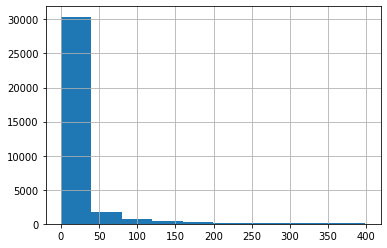

In [44]:

norder["last"] = (norder["uts"] - norder["cts"])/1000
norder[norder["ttype"] == "maker"]["last"].hist()

In [45]:
pd.to_datetime(norder["cts"].min() + 8*3600000, unit="ms"),pd.to_datetime(norder["cts"].max() + 8*3600000, unit="ms")

(Timestamp('2024-02-13 14:15:11'), Timestamp('2024-02-17 07:59:36'))